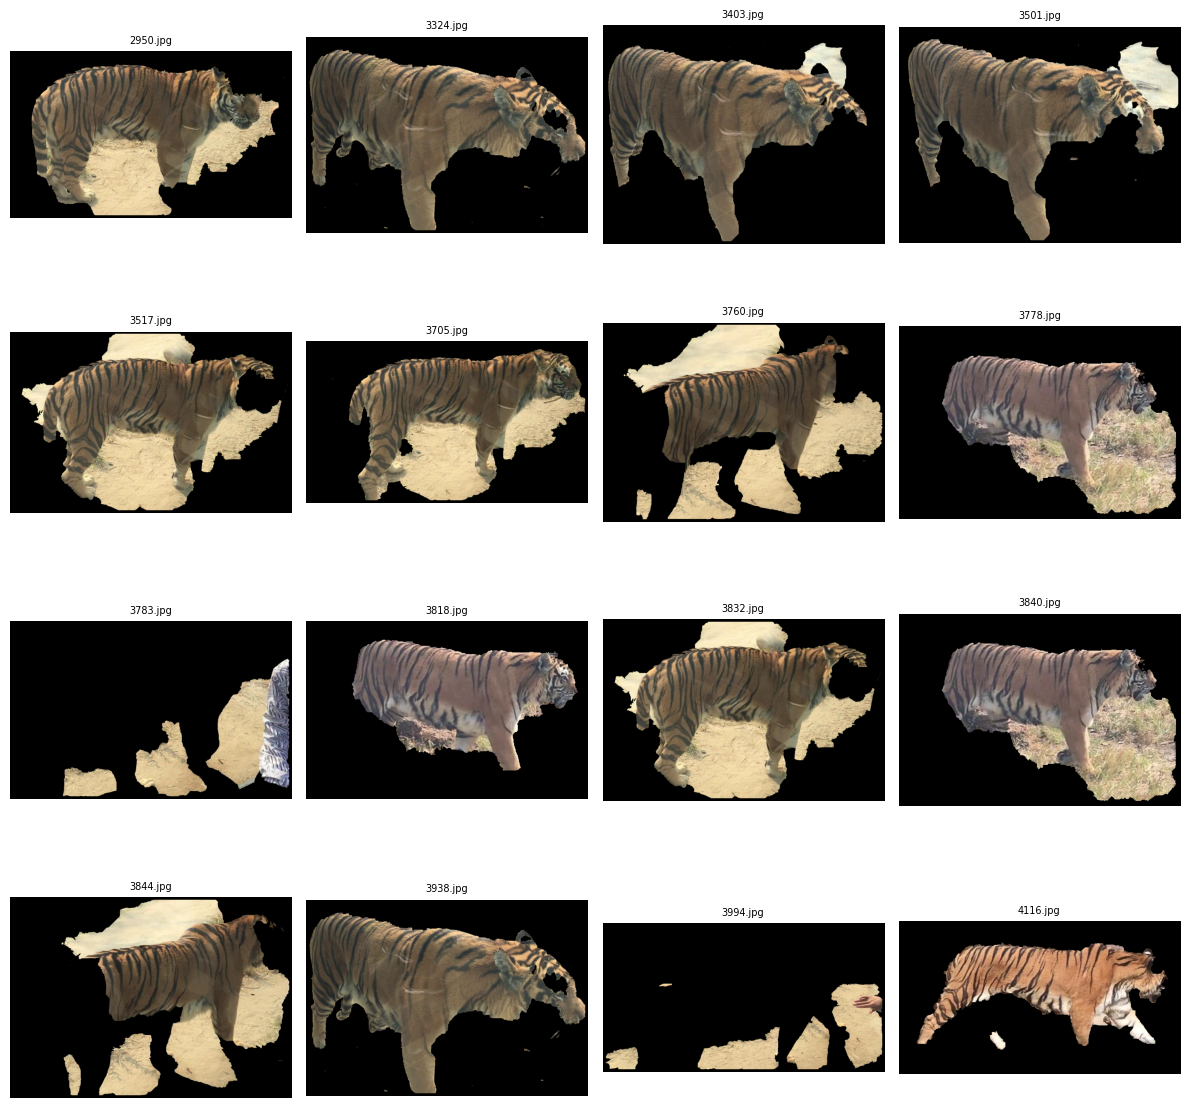

: 

In [ ]:
# Cell 1 ▸ imports & parameters
from pathlib import Path
import cv2, numpy as np, matplotlib.pyplot as plt

IM_DIR   = Path("../data/ATRW/dataset/ATRW_7")   # ← adjust
MAX_SHOW = 16                                     # how many to display
LONG_MAX = 1024                                   # long side after resize

# ──────────────────────────────────────────────────────────────────────
def quick_mask_and_resize(img_bgr, long_max=LONG_MAX):
    """
    Returns (img_resized, mask) where both share the same H×W.
    Mask is uint8 {0,1}.
    """
    h, w = img_bgr.shape[:2]
    if max(h, w) > long_max:
        scale = long_max / max(h, w)
        img_bgr = cv2.resize(img_bgr, (int(w*scale), int(h*scale)), cv2.INTER_AREA)

    # --- very light enhancement -------------------------------------
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    hsv[..., 2] = cv2.equalizeHist(hsv[..., 2])
    img_bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
    img_bgr = cv2.bilateralFilter(img_bgr, 7, 60, 25)

    # --- threshold + morphology -------------------------------------
    v = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)[..., 2]
    mask = (v > np.percentile(v, 90)).astype(np.uint8)

    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((15,15), np.uint8))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  np.ones((7,7),  np.uint8))
    mask = cv2.dilate(mask, np.ones((7,7), np.uint8), 2)

    return img_bgr, mask


def show_grid(paths):
    n     = len(paths)
    cols  = 4
    rows  = int(np.ceil(n/cols))
    plt.figure(figsize=(3*cols, 3*rows))
    for i, p in enumerate(paths):
        img = cv2.imread(str(p))
        img, mask = quick_mask_and_resize(img)

        edge = cv2.Canny(mask*255, 50, 150)
        vis  = img.copy()
        vis[edge > 0] = (0, 0, 255)                # red outline
        vis = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)

        plt.subplot(rows, cols, i+1)
        plt.imshow(vis)
        plt.title(p.name, fontsize=7)
        plt.axis("off")
    plt.tight_layout()
# ──────────────────────────────────────────────────────────────────────



# ───────────────────────────────────────────────────────────────────
def robust_mask(img_bgr, long_max=LONG_MAX, iters=5):
    """
    Returns (img_resized, final_mask{0,1})
    1. quick HSV/Lab threshold → coarse FG
    2. GrabCut refinement (CPU)
    """
    # ----- resize --------------------------------------------------
    h, w = img_bgr.shape[:2]
    if max(h, w) > long_max:
        s = long_max / max(h, w)
        img_bgr = cv2.resize(img_bgr, (int(w*s), int(h*s)), cv2.INTER_AREA)

    # ----- coarse FG: union of bright OR colourful -----------------
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)

    bright = hsv[..., 2] > np.percentile(hsv[..., 2], 80)          # brightness
    colour = lab[..., 1] > np.percentile(lab[..., 1], 70)          # a* channel (reds/browns)

    coarse = np.logical_or(bright, colour).astype(np.uint8)

    # remove tiny blobs / close holes
    coarse = cv2.morphologyEx(coarse, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8))
    coarse = cv2.morphologyEx(coarse, cv2.MORPH_OPEN,  np.ones((5, 5), np.uint8))

    # ----- build GrabCut trimap -----------------------------------
    mask_gc = np.full(coarse.shape, cv2.GC_PR_BGD, dtype=np.uint8)
    mask_gc[coarse == 1] = cv2.GC_PR_FGD

    # force 10-pixel border to background (helps when crop is too tight)
    mask_gc[:10, :]  = cv2.GC_BGD
    mask_gc[-10:, :] = cv2.GC_BGD
    mask_gc[:, :10]  = cv2.GC_BGD
    mask_gc[:, -10:] = cv2.GC_BGD

    # ----- GrabCut refinement -------------------------------------
    cv2.grabCut(img_bgr, mask_gc, None, np.zeros((1,65),np.float64),
                np.zeros((1,65),np.float64), iters, cv2.GC_INIT_WITH_MASK)

    final = np.where((mask_gc == cv2.GC_FGD)|(mask_gc == cv2.GC_PR_FGD), 1, 0).astype(np.uint8)
    return img_bgr, final

def show_grid(paths, n_show=N_SHOW):
    cols = 4
    rows = int(np.ceil(min(n_show, len(paths))/cols))
    plt.figure(figsize=(3*cols, 3*rows))
    for i, p in enumerate(paths[:n_show]):
        img = cv2.imread(str(p))
        img, m = robust_mask(img)
        edge = cv2.Canny(m*255, 50, 150)
        vis  = img.copy()
        vis[edge>0] = (0,0,255)           # red outline
        vis = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
        plt.subplot(rows, cols, i+1)
        plt.imshow(vis)
        plt.title(p.name, fontsize=7)
        plt.axis("off")
    plt.tight_layout()

# ------------------------------------------------------------------
all_imgs = sorted([p for p in IM_DIR.iterdir()
                   if p.suffix.lower() in {".jpg",".jpeg",".png"}])

show_masked_grid(all_imgs)
